### EDA📊

Dans ce notebook, nous allons :
1. Charger les données nettoyées depuis `data/processed/`.
2. Définir les étapes du funnel.
3. Calculer les KPI with `funnel_metrics.py` and `funnel_analysis_functions.py`.
4. Visualiser les drop-offs et conversions avec `visualization_utils.py`.

In [1]:
import sys
import pandas as pd
from pathlib import Path

src_path = Path.cwd().parent / "src"
sys.path.append(str(src_path))

from utils import setup_logger, ensure_directory_exists
from funnel_analysis_functions import get_funnel_stages
from funnel_metrics import calculate_funnel_metrics, calculate_conversion_by_dimension
import visualization_utils
from visualization_utils import plot_funnel_chart, plot_dropoff_analysis, plot_conversion_by_dimension, plot_conversion_vs_duration
from IPython.display import display

LOG_PATH = str(Path.cwd().parent / "reports/logs/data_exploration.log")
ensure_directory_exists(str(Path(LOG_PATH).parent))
logger = setup_logger(LOG_PATH)

print("✅ Modules importés")

✅ Modules importés


## 1. Chargement des données processées

In [2]:
PROCESSED_DATA_PATH = str(Path.cwd().parent / "data/processed/bank-marketing_cleaned.csv")
df_clean = pd.read_csv(PROCESSED_DATA_PATH, sep=';')

print(f"✅ Données chargées : {df_clean.shape}")
display(df_clean.head(2))

✅ Données chargées : (775, 20)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y,converted,showed_interest,funnel_stage
0,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no,0,1,Highly_Engaged
1,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no,0,1,Highly_Engaged


## 2. Définition et Calcul des Étapes du Funnel

In [3]:
stages = get_funnel_stages(df_clean)
metrics = calculate_funnel_metrics(df_clean, stages)

print("📊 Étapes :")
for k, v in stages.items():
    print(f"  {k}: {v:,}")

print("\n📈 Métriques :")
for k, v in metrics.items():
    print(f"  {k}: {v}")

📊 Étapes :
  Impressions: 775
  Contacted: 775
  Engaged: 694
  Converted: 173

📈 Métriques :
  contact_rate: 100.0
  engagement_rate: 89.54838709677419
  conversion_rate: 22.322580645161292
  contact_to_engaged_dropoff: 10.451612903225808
  engaged_to_converted_dropoff: 75.07204610951008
  avg_duration_sec: 271.35
  conversion_by_interest_pct: 22.32


- **Analysis**:

Le taux d'engagement est extrêmement élevé (**89.5%**). Cela signifie que la quasi-totalité des clients contactés (775) acceptent d'échanger et montrent un intérêt pour l'offre. La perte à cette étape n'est que de **10.4%**.

 **Le Goulot d'étranglement (Drop-off effectif)** : Le point de friction majeur se situe à la dernière étape (Engagé ➔ Converti). Parmi les prospects engagés, **75% abandonnent** avant de souscrire. 

 **Taux de conversion final** : Il se situe à **22.3%**, ce qui est dans les standards élevés d'une campagne marketing téléphonique bien ciblée.

## 3. Visualisation du Funnel et des Drop-offs

✅ Funnel chart sauvegardé : e:\Certifs\Future_Interns\FUTURE_DS_03\reports\images/funnel_chart.png


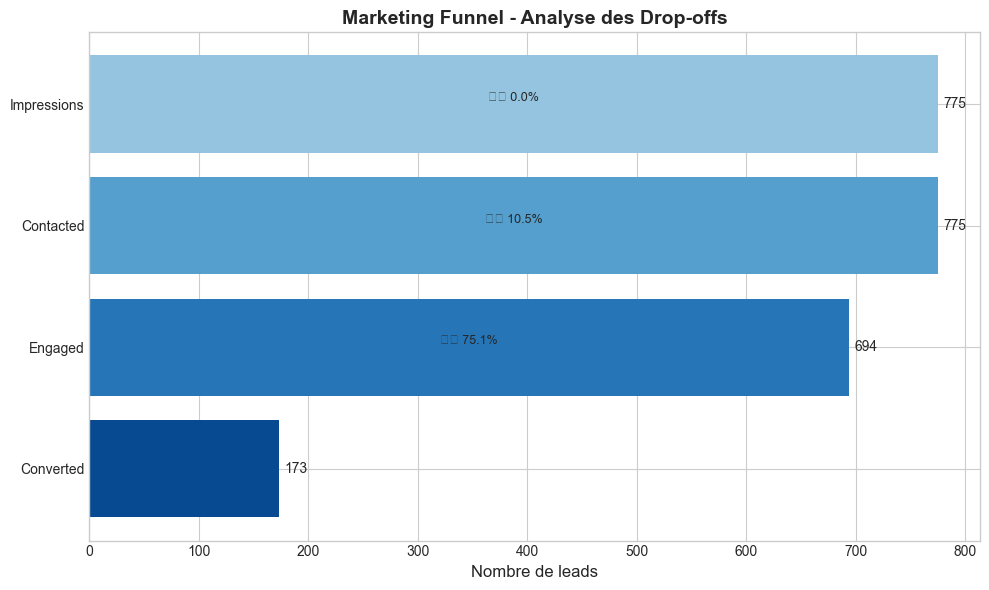

In [5]:
IMAGES_PATH = str(Path.cwd().parent / "reports/images")
ensure_directory_exists(IMAGES_PATH)

plot_funnel_chart(stages, save_path=f"{IMAGES_PATH}/funnel_chart.png")

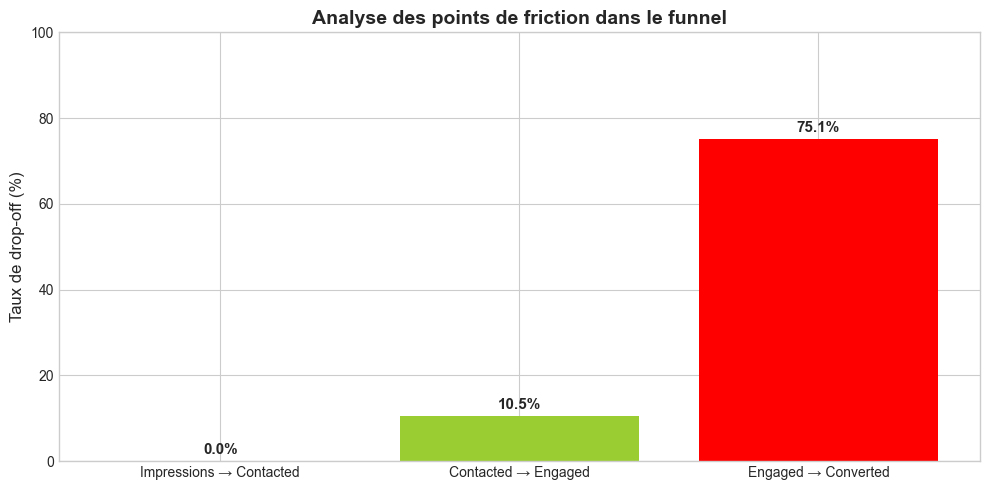

In [6]:
plot_dropoff_analysis(stages, save_path=f"{IMAGES_PATH}/dropoff_analysis.png")

Le début du funnel est extrêmement performant. Il n'y a aucune déperdition entre les impressions et les contacts `(0%)`, et une très faible perte lors de l'engagement (seulement `10.5%` de déperdition entre "Contacted" et "Engaged"). L'audience cible est donc très réceptive au premier abord.

* **Le Goulot d'Étranglement (Friction majeure)** : Le point critique se situe à la toute fin du processus de vente. Sur les `694` prospects engagés, **`75.1%` abandonnent** avant la conversion finale. 

* **Recommandation Stratégique** : C'est ici que l'effort commercial doit se porter. L'équipe marketing/vente n'a pas de problème pour attirer l'attention, mais elle a du mal à *conclure la vente* (closing). Il faudrait analyser les objections finales des clients (Prix ? Modalités contractuelles ?) pour réduire cette chute de `75.1%`.

## 4. Analyse des Conversions (par Dimension et Durée)

✅ Graphique sauvegardé : e:\Certifs\Future_Interns\FUTURE_DS_03\reports\images/conversion_by_dimension_job.png


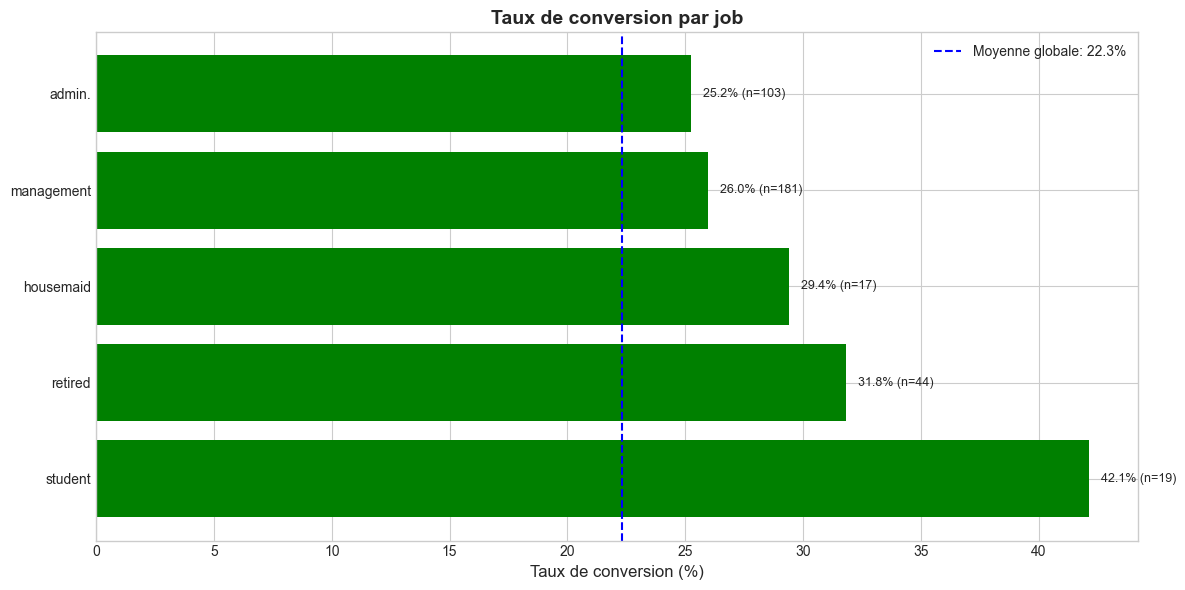

In [11]:
plot_conversion_by_dimension(df_clean, dimension='job', top_n=5, save_path=f"{IMAGES_PATH}/conversion_by_dimension_job.png")

Le taux de conversion global moyen de la campagne est de `22.3%`. Cependant, l'analyse par profession révèle de fortes disparités :

* **Les niches ultra-performantes (Faible volume, fort potentiel)** : Les **étudiants** (*student*) écrasent littéralement la moyenne avec un taux de conversion de `42.1%`, suivis par les **retraités** (*retired*) à `31.8%`. Ces cibles sont très réceptives à l'offre bancaire proposée, bien que leur volume actuel soit faible `(n=19 et n=44)`.

* **Le cœur de cible fiable (Fort volume, bonne performance)** : Les postes de **Management** (*management*) et d'**Administration** (*admin.*) performent tous deux au-dessus de la moyenne `(26% et 25.2%)`, tout en apportant le plus gros volume de leads (respectivement n=181 et n=103). 

* **Actionable Insight** : Pour une prochaine campagne, allouer plus de budget pour le ciblage spécifique des étudiants et retraités pourrait considérablement gonfler le ratio de rentabilité.

✅ Graphique sauvegardé : e:\Certifs\Future_Interns\FUTURE_DS_03\reports\images/conversion_by_dimension_contact.png


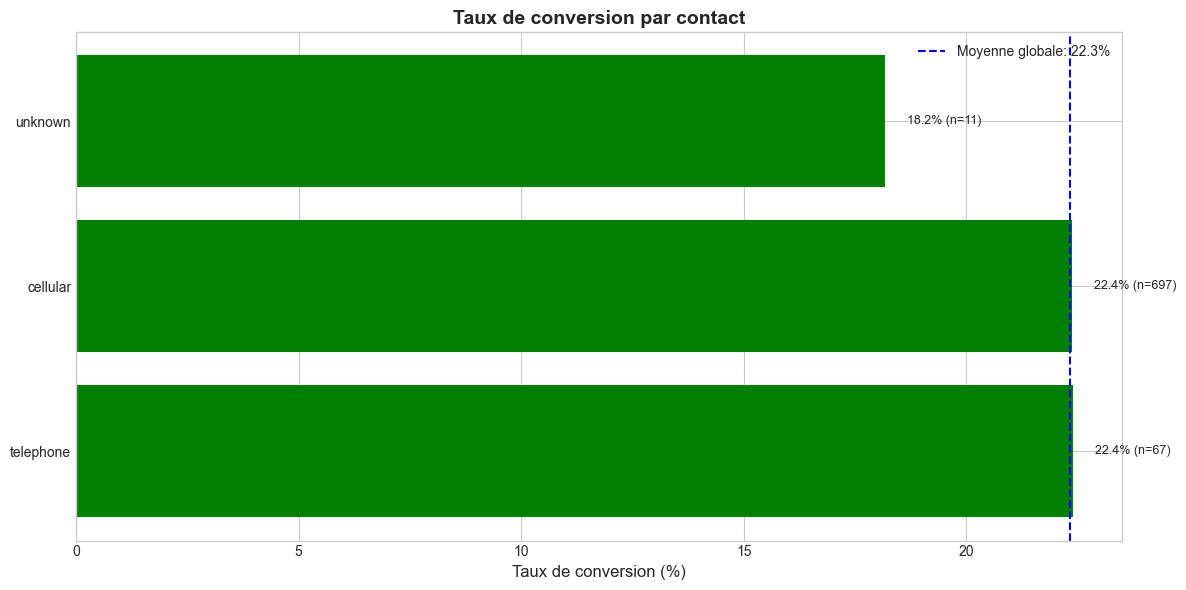

In [ ]:
plot_conversion_by_dimension(df_clean, dimension='contact', top_n=3, save_path=f"{IMAGES_PATH}/conversion_by_dimension_contact.png")

* **Hégémonie du mobile** : Le canal **Cellular** (téléphone portable) représente l'écrasante majorité des contacts qualifiés de la campagne `(n=697)`, loin devant le téléphone fixe (*telephone*, `n=67`).

* **Aucune différence de performance** : Contrairement aux idées reçues, le taux de conversion entre les téléphones portables et les fixes est **strictement identique `(22.4%)`**. Le canal de communication ne modifie pas l'appétence du client au produit.

* La catégorie "unknown" est sous-performante `(18.2%)`, mais son volume `(n=11)` est statistiquement marginalisé.

2026-04-11 10:45:23,569 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-04-11 10:45:23,577 - INFO - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


e:\Certifs\Future_Interns\FUTURE_DS_03\src\visualization_utils.py:155: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non-convertis', 'Convertis'])


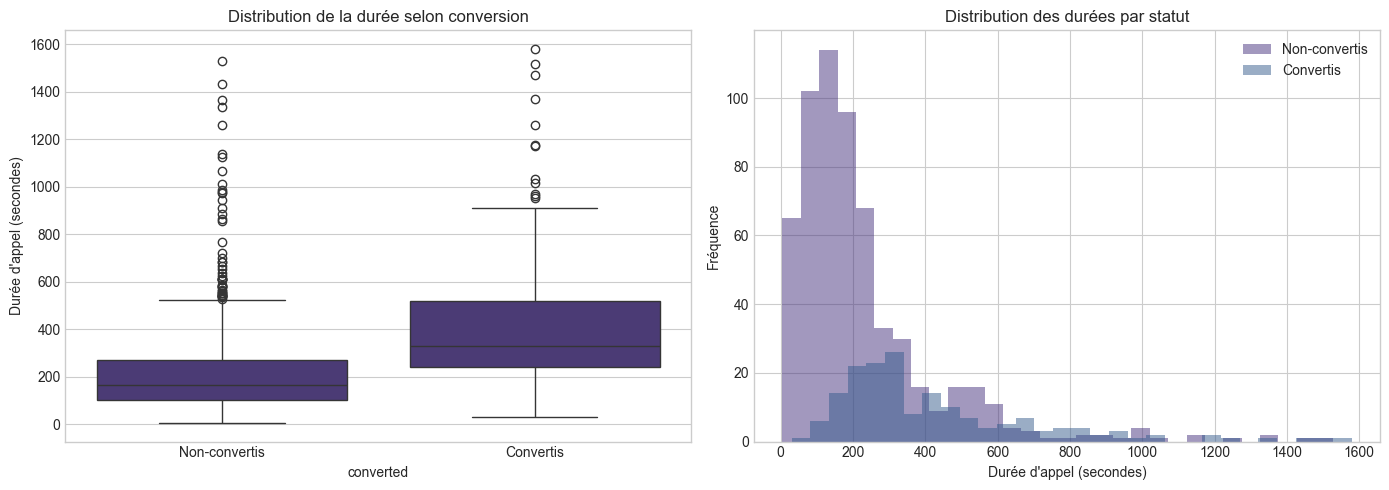

In [13]:
plot_conversion_vs_duration(df_clean, save_path=f"{IMAGES_PATH}/conversion_vs_duration.png")

Observation : L'Indicateur Clé de la Durée d'Appel (Duration)


* **Une corrélation flagrante** : On observe une différence nette entre la durée médiane d'un appel non-converti (autour de `150-200 secondes`) et celle d'un appel converti (qui s'allonge vers les` 300-350 secondes`).

* **La zone de bascule** : En regardant l'histogramme, on constate que la grande majorité des "Non-convertis" (en violet) coupe court très tôt à l'échange. À l'inverse, si l'appel dépasse les **`300 à 400 secondes` (~5 à 7 minutes)**, les chances de conversion `(en bleu)` augmentent significativement.

* **⚠️ Mise en garde métier** : Comme stipulé souvent en data science, la *duration* est une variable **"Data Leakage"** (fuite de données) : on ne connait la durée de l'appel qu'une fois celui-ci terminé. Elle ne peut donc pas être utilisée dans un modèle de *prédiction* pur en amont, mais c'est l'indicateur d'intérêt le plus fort une fois l'interaction commencée.